# QA, diffusion kernel, and RWR on a 20-site chain

This toy model uses an undirected chain with 20 vertices and two seeds at the boundaries (sites 0 and 19). Quantum adjacency-walk (QA) and diffusion-kernel (DK) densities are compared at several times. Random walk with restart (RWR) scores are compared at five restart probabilities.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "bioGraph").is_dir():
    raise FileNotFoundError(
        "Start Jupyter from the repository root or the notebooks directory."
    )
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.sparse import csr_matrix

from bioGraph.methods.ranking import (
    dk_score,
    normalize_adjacency,
    qa_score,
    rwr_score,
)

## Toy model

For QA, the chain adjacency matrix is used as the Hamiltonian, $H=A$. For DK, the combinatorial graph Laplacian $L=D-A$ generates the diffusion. RWR uses the symmetrically normalized adjacency matrix already used by the project implementation.

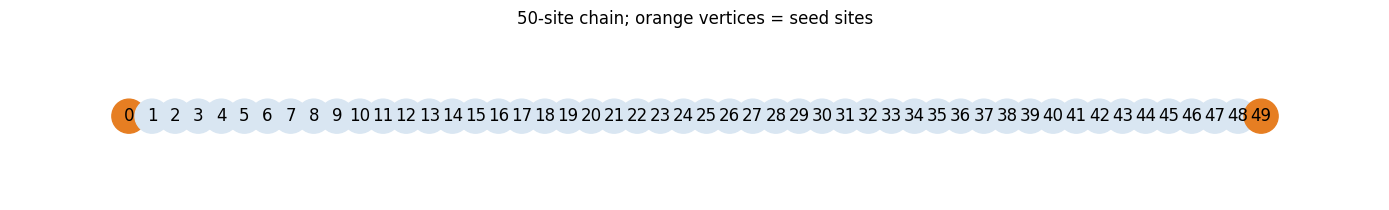

In [31]:
number_of_sites = 50
seed_sites = [0, number_of_sites - 1]
chain = nx.path_graph(number_of_sites)
nodelist = list(range(number_of_sites))
sites = np.asarray(nodelist)

adjacency = csr_matrix(nx.to_numpy_array(chain, nodelist=nodelist, dtype=float))
laplacian = csr_matrix(nx.laplacian_matrix(chain, nodelist=nodelist))
normalized_adjacency = normalize_adjacency(
    chain, adjacency, nodelist=nodelist
)

fig, ax = plt.subplots(figsize=(14, 2.2))
positions = {site: (site, 0) for site in nodelist}
node_colors = ["#E67E22" if site in seed_sites else "#D9E6F2" for site in nodelist]
nx.draw_networkx(
    chain,
    positions,
    ax=ax,
    node_color=node_colors,
    node_size=600,
    edge_color="#555555",
    width=2.5,
    with_labels=True,
)
ax.set_title(f"{number_of_sites}-site chain; orange vertices = seed sites")
ax.axis("off")
plt.tight_layout()
plt.show()

In [32]:
time_values = [0.5, 1.0, 2.0, 5.0, 10,1e3]
restart_probabilities = [0.1, 0.3, 0.5, 0.7, 0.9]

qa_densities = {
    time: qa_score(
        chain,
        seed_sites,
        t=time,
        H=adjacency.copy(),
        nodelist=nodelist,
    )
    for time in time_values
}

dk_densities = {
    time: dk_score(
        chain,
        seed_sites,
        t=time,
        L=laplacian,
        nodelist=nodelist,
    )
    for time in time_values
}

rwr_scores = {
    probability: rwr_score(
        chain,
        seed_sites,
        normalized_adjacency=normalized_adjacency,
        return_prob=probability,
        nodelist=nodelist,
    )
    for probability in restart_probabilities
}

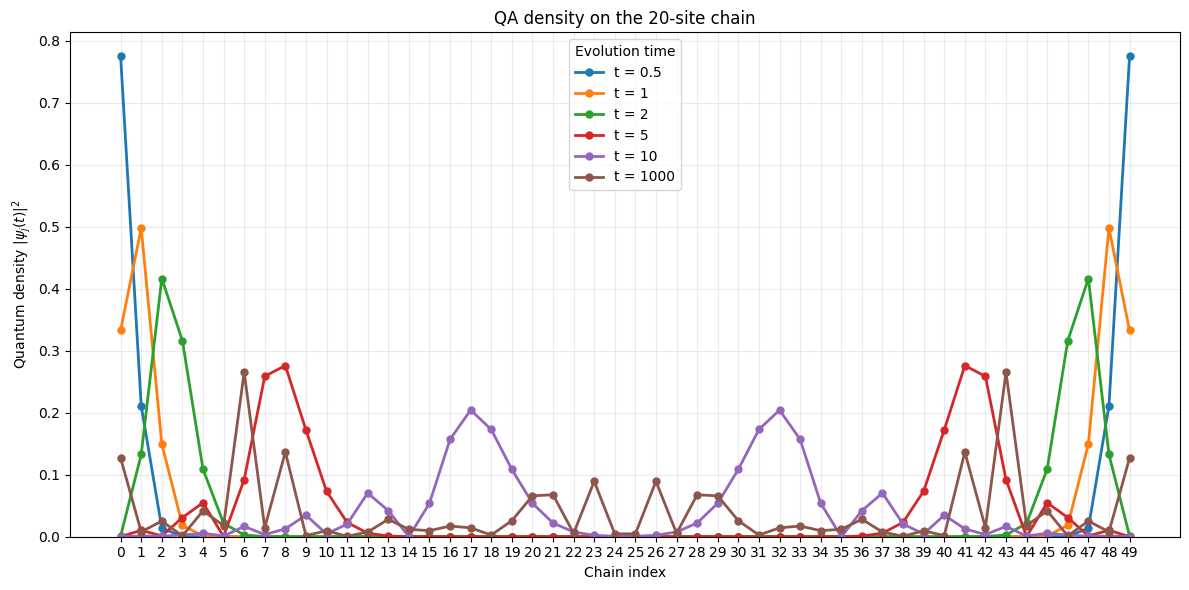

In [33]:
fig, ax = plt.subplots(figsize=(12, 6))
for time, density in qa_densities.items():
    ax.plot(sites, density, marker="o", linewidth=2, markersize=5, label=f"t = {time:g}")

ax.set(
    title="QA density on the 20-site chain",
    xlabel="Chain index",
    ylabel=r"Quantum density $|\psi_j(t)|^2$",
)
ax.set_xticks(sites)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend(title="Evolution time")
plt.tight_layout()
plt.show()

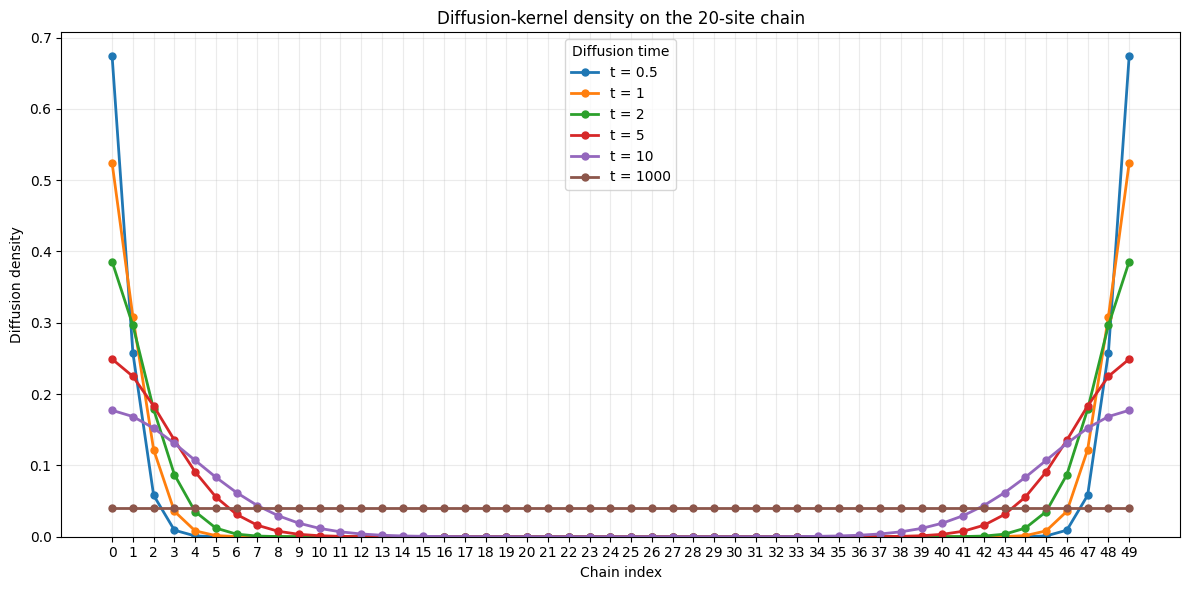

In [34]:
fig, ax = plt.subplots(figsize=(12, 6))
for time, density in dk_densities.items():
    ax.plot(sites, density, marker="o", linewidth=2, markersize=5, label=f"t = {time:g}")

ax.set(
    title="Diffusion-kernel density on the 20-site chain",
    xlabel="Chain index",
    ylabel="Diffusion density",
)
ax.set_xticks(sites)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend(title="Diffusion time")
plt.tight_layout()
plt.show()

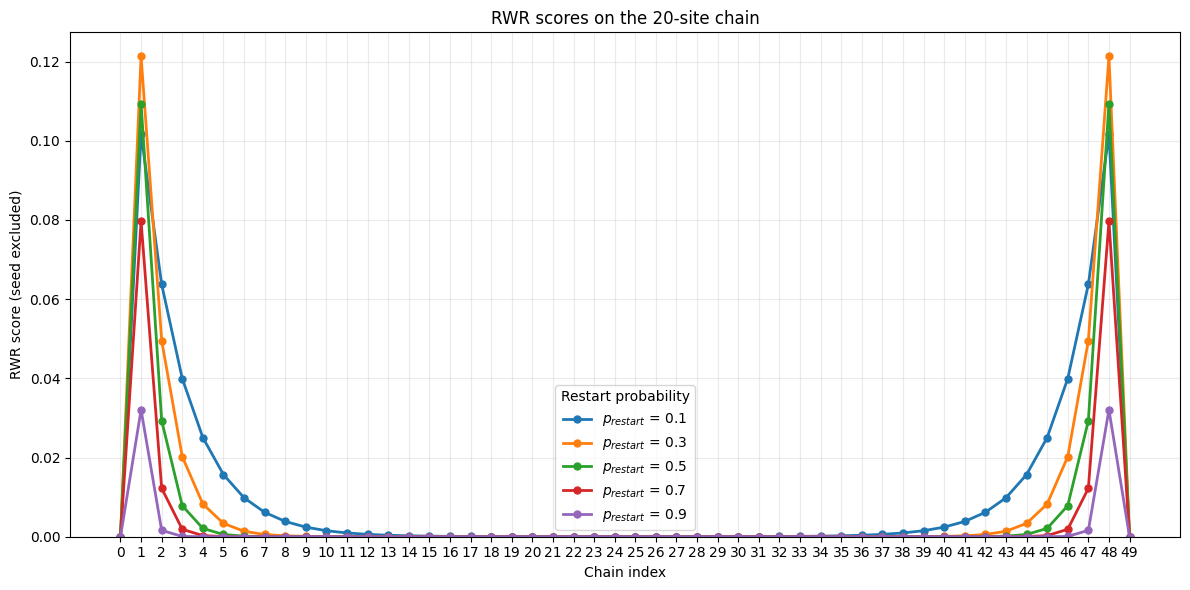

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))
for probability, scores in rwr_scores.items():
    ax.plot(
        sites,
        scores,
        marker="o",
        linewidth=2,
        markersize=5,
        label=fr"$p_{{restart}}$ = {probability:g}",
    )

ax.set(
    title="RWR scores on the 20-site chain",
    xlabel="Chain index",
    ylabel="RWR score (seed excluded)",
)
ax.set_xticks(sites)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend(title="Restart probability")
plt.tight_layout()
plt.show()

**RWR convention:** `bioGraph.methods.ranking.rwr_score` sets the original seed's returned score to zero because the project ranks only non-seed candidates. The RWR curves therefore show candidate scores rather than a normalized probability distribution over all 20 sites.

In [7]:
print("Density / score sums")
print("QA:", {time: float(values.sum()) for time, values in qa_densities.items()})
print("DK:", {time: float(values.sum()) for time, values in dk_densities.items()})
print(
    "RWR (seed-excluded):",
    {probability: float(values.sum()) for probability, values in rwr_scores.items()},
)

Density / score sums
QA: {0.1: 1.0000000000000002, 0.5: 1.0, 1.0: 1.0000000000000004, 2.0: 0.9999999999999999, 5.0: 1.0000000000000007}
DK: {0.1: 0.9999999999999999, 0.5: 1.0, 1.0: 0.9999999999999998, 2.0: 1.0000000000000002, 5.0: 0.9999999999999997}
RWR (seed-excluded): {0.1: 0.5449042133709948, 0.3: 0.4100625964820154, 0.5: 0.2988585687839465, 0.7: 0.1882322395086774, 0.9: 0.06750461177858112}


## QA interference from the relative seed phase

The project `qa_score` function evolves each seed as a separate localized state and adds their probabilities. Such an incoherent sum cannot depend on relative phase. To study interference, the following cell instead prepares the normalized coherent initial state

$$|\psi(0)\rangle = \frac{1}{\sqrt{2}}\left(|s_1\rangle + e^{i\Delta\phi}|s_2\rangle\right),$$

then evolves it with the same adjacency Hamiltonian, $|\psi(t)\rangle=e^{-itA}|\psi(0)\rangle$. The four panels use relative phases from $0$ to $\pi$.

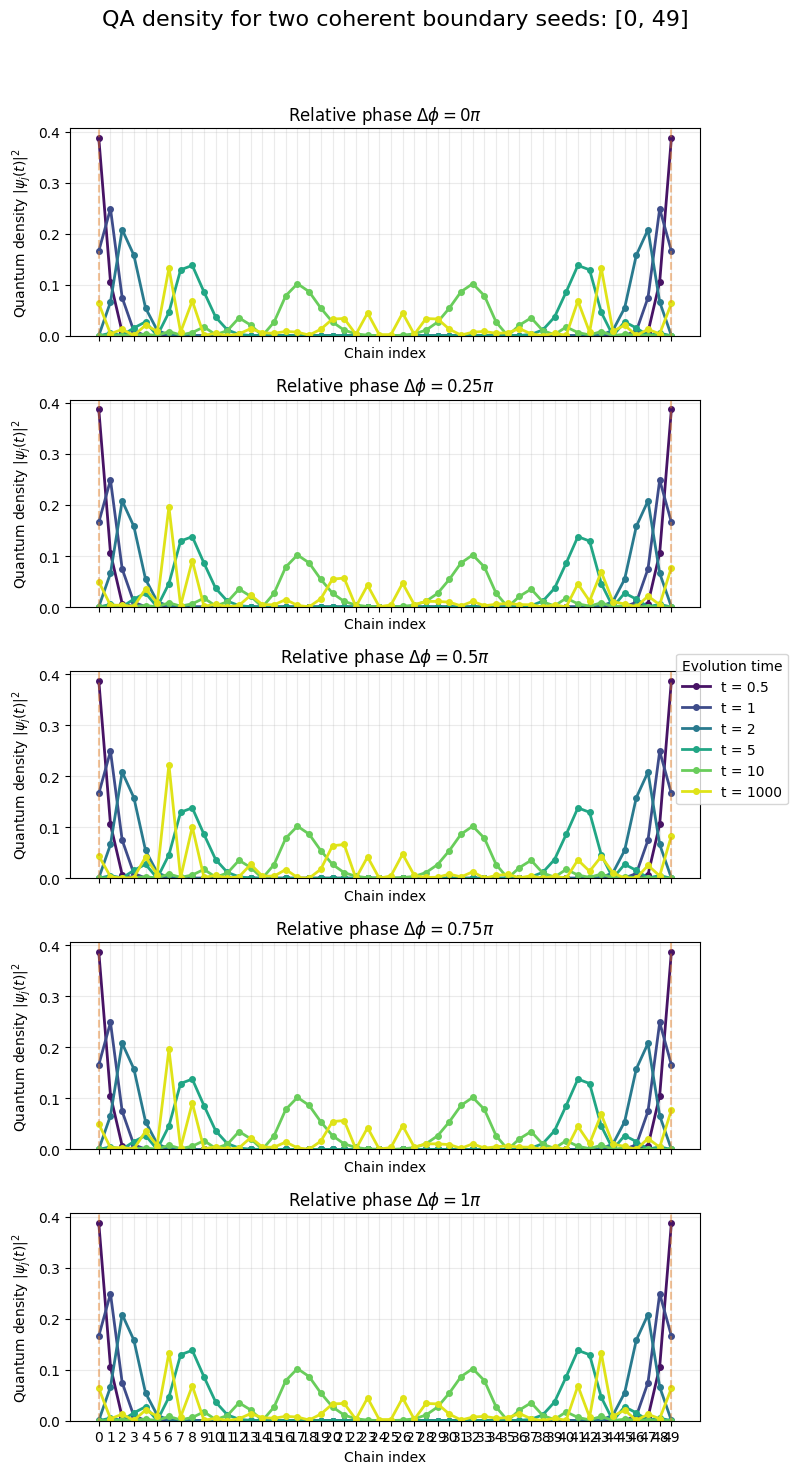

{0.0: {0.5: 0.9999999999999994,
  1.0: 0.9999999999999999,
  2.0: 0.9999999999999994,
  5.0: 0.9999999999999996,
  10: 1.000000000000002,
  1000.0: 1.0000000000008578},
 0.7853981633974483: {0.5: 0.9999999999999996,
  1.0: 1.0,
  2.0: 0.9999999999999996,
  5.0: 0.9999999999999998,
  10: 0.9999999999999991,
  1000.0: 1.00000000000084},
 1.5707963267948966: {0.5: 0.9999999999999994,
  1.0: 0.9999999999999999,
  2.0: 0.9999999999999994,
  5.0: 0.9999999999999993,
  10: 1.0000000000000027,
  1000.0: 1.0000000000003455},
 2.356194490192345: {0.5: 0.9999999999999996,
  1.0: 1.0,
  2.0: 0.9999999999999996,
  5.0: 0.9999999999999998,
  10: 1.0,
  1000.0: 1.0000000000012323},
 3.141592653589793: {0.5: 0.9999999999999994,
  1.0: 0.9999999999999999,
  2.0: 0.9999999999999994,
  5.0: 0.9999999999999996,
  10: 1.000000000000002,
  1000.0: 1.0000000000010987}}

In [37]:
from scipy.sparse.linalg import expm_multiply

if len(seed_sites) != 2:
    raise ValueError("The relative-phase analysis requires exactly two seed sites.")

relative_phases = np.linspace(0.0, np.pi, 5)
phase_densities = {}

for relative_phase in relative_phases:
    initial_state = np.zeros(number_of_sites, dtype=np.complex128)
    initial_state[seed_sites[0]] = 1.0 / np.sqrt(2.0)
    initial_state[seed_sites[1]] = np.exp(1j * relative_phase) / np.sqrt(2.0)
    phase_densities[relative_phase] = {
        time: np.abs(
            expm_multiply(-1j * time * adjacency, initial_state)
        ) ** 2
        for time in time_values
    }

fig, axes = plt.subplots(5, 1, figsize=(8, 15), sharex=True, sharey=True)
time_colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(time_values)))

for ax, relative_phase in zip(axes.ravel(), relative_phases):
    for color, time in zip(time_colors, time_values):
        ax.plot(
            sites,
            phase_densities[relative_phase][time],
            color=color,
            marker="o",
            linewidth=2,
            markersize=4,
            label=f"t = {time:g}",
        )
    for seed_site in seed_sites:
        ax.axvline(seed_site, color="#E67E22", linestyle="--", alpha=0.45)
    ax.set_title(fr"Relative phase $\Delta\phi = {relative_phase / np.pi:.2g}\pi$")
    ax.set_xticks(sites)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)
    ax.set_xlabel("Chain index")
    ax.set_ylabel(r"Quantum density $|\psi_j(t)|^2$")

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    title="Evolution time",
    loc="center right",
    bbox_to_anchor=(1.0, 0.5),
)
fig.suptitle(
    f"QA density for two coherent boundary seeds: {seed_sites}", fontsize=16
)
plt.tight_layout(rect=(0, 0, 0.9, 0.95))
plt.show()

# Unitary evolution should preserve the normalized coherent-state density.
phase_density_sums = {
    relative_phase: {
        time: float(density.sum())
        for time, density in densities_by_time.items()
    }
    for relative_phase, densities_by_time in phase_densities.items()
}
phase_density_sums

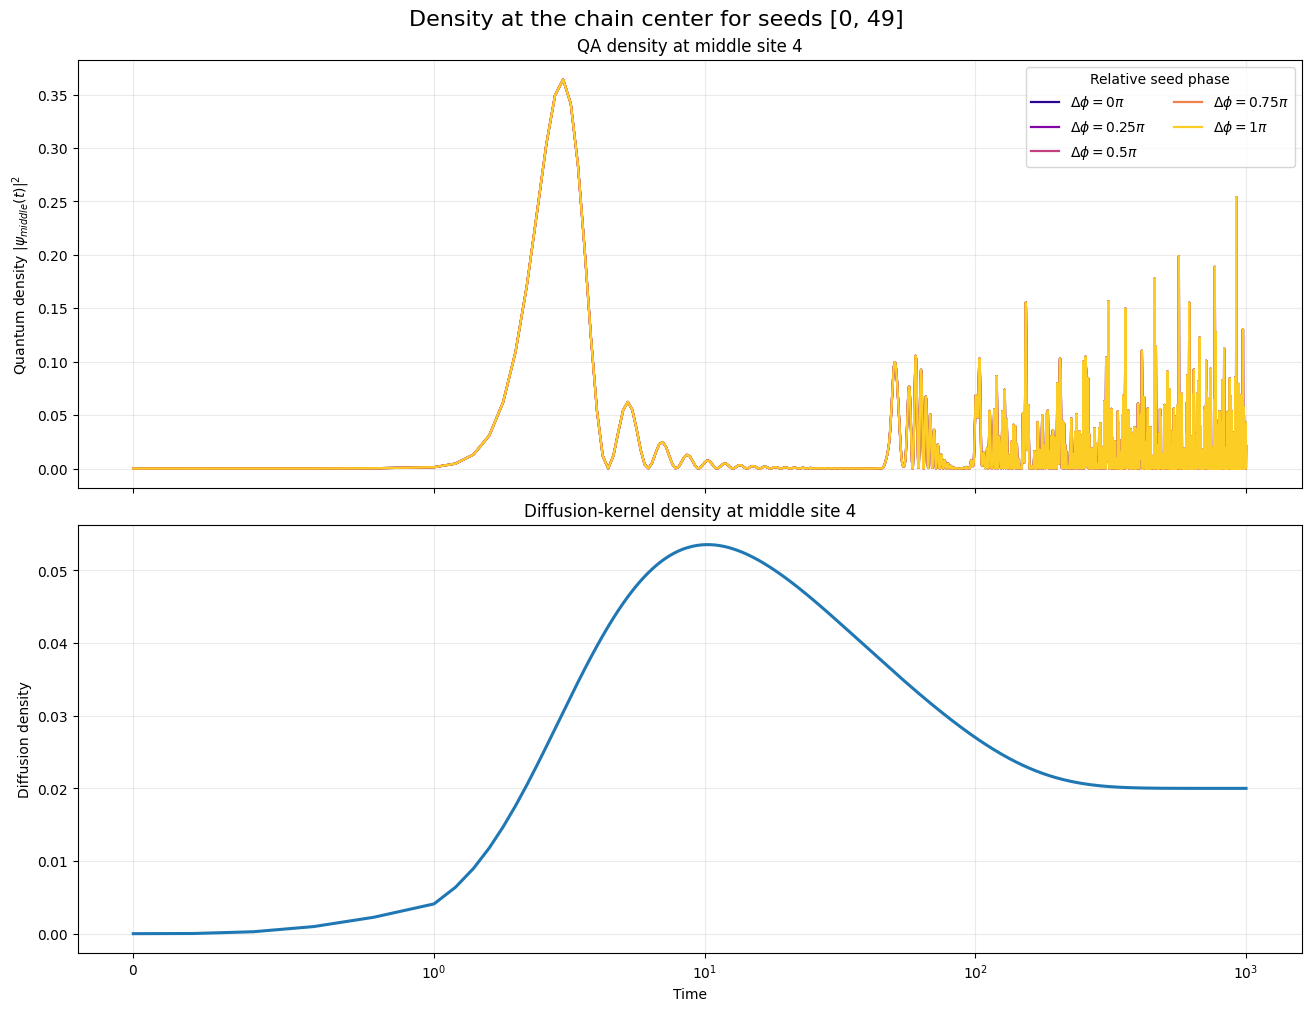

In [41]:
# Density at the middle of the chain as a function of time.
# For an even chain, choose the left of the two central sites.
middle_site = 4
maximum_scan_time = float(max(time_values))
middle_time_grid = np.linspace(0.0, maximum_scan_time, 5001)

qa_middle_density = {}
for relative_phase in relative_phases:
    initial_state = np.zeros(number_of_sites, dtype=np.complex128)
    initial_state[seed_sites[0]] = 1.0
    evolved_states = expm_multiply(
        -1j * adjacency,
        initial_state,
        start=0.0,
        stop=maximum_scan_time,
        num=len(middle_time_grid),
        endpoint=True,
    )
    qa_middle_density[relative_phase] = np.abs(
        evolved_states[:, middle_site]
    ) ** 2

# Classical diffusion starts with equal probability on the two seeds.
diffusion_initial_state = np.zeros(number_of_sites, dtype=float)
diffusion_initial_state[seed_sites] = 1.0 / len(seed_sites)
diffusion_states = expm_multiply(
    -laplacian,
    diffusion_initial_state,
    start=0.0,
    stop=maximum_scan_time,
    num=len(middle_time_grid),
    endpoint=True,
)
dk_middle_density = diffusion_states[:, middle_site]

fig, (ax_qa, ax_dk) = plt.subplots(
    2, 1, figsize=(13, 10), sharex=True, constrained_layout=True
)

phase_colors = plt.cm.plasma(np.linspace(0.05, 0.9, len(relative_phases)))
for color, relative_phase in zip(phase_colors, relative_phases):
    ax_qa.plot(
        middle_time_grid,
        qa_middle_density[relative_phase],
        color=color,
        linewidth=1.6,
        label=fr"$\Delta\phi={relative_phase / np.pi:.2g}\pi$",
    )
ax_qa.set_title(f"QA density at middle site {middle_site}")
ax_qa.set_ylabel(r"Quantum density $|\psi_{middle}(t)|^2$")
ax_qa.legend(title="Relative seed phase", ncol=2)
ax_qa.grid(alpha=0.25)

ax_dk.plot(
    middle_time_grid,
    dk_middle_density,
    color="#1F77B4",
    linewidth=2.2,
)
ax_dk.set_title(f"Diffusion-kernel density at middle site {middle_site}")
ax_dk.set_xlabel("Time")
ax_dk.set_ylabel("Diffusion density")
ax_dk.grid(alpha=0.25)

# The symmetric-log scale resolves both early propagation and long-time behavior.
ax_dk.set_xscale("symlog", linthresh=1.0)
fig.suptitle(
    f"Density at the chain center for seeds {seed_sites}", fontsize=16
)
plt.show()